# Evaluation

- Evaluate training and test data distributions
- Display feature importances
- Inspect SHAP results

In [27]:
import xgboost as xgb
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import xarray as xr
import dask.dataframe as dd

from skimage.metrics import structural_similarity as ssim
import shap
from scores.spatial import fss_2d

import yaml
import os

In [2]:
model = xgb.XGBRegressor()

# Load Model and Data

In [3]:
config_name = 'b-rad'
# Get configurations from yaml file
with open(f"/home/548/cd3022/repos/solar-nowcast/configs/mouse/{config_name}.yaml") as f:
    config = yaml.safe_load(f)
# Model
model_name = config["model"]["name"]
forecast_lead = config["model"]["forecast_lead"]
# Parameters
random_state = config["model"]["parameters"]["random_state"]
n_estimators = config["model"]["parameters"]["n_estimators"]
early_stopping_rounds = config["model"]["parameters"]["early_stopping_rounds"]
learning_rate = config["model"]["parameters"]["learning_rate"]
eval_metric = config["model"]["parameters"]["eval_metric"]

# Data
X_vars = config["data"]["predictors"]
target = config["data"]["target"]
y_var = f'{target}_t{forecast_lead}'
all_vars = X_vars + [y_var]

In [4]:
model.load_model(f"/scratch/er8/cd3022/xgb_models/{model_name}.json")

In [5]:
data_path = Path('/scratch/er8/cd3022/xgb_datasets/')

test_files = []

for f in data_path.glob("all_training_month*"):
    month = f.name.split("_")[-1][:2]  # adjust to your naming

    if month in ['02', '06', '10']:
        test_files.append(str(f))

df = dd.read_parquet(test_files, columns=all_vars)
df = df.compute()

In [6]:
X = df[X_vars]

preds = model.predict(X)

df[f'xgb_t{forecast_lead}'] = preds
ds_xgb = df.to_xarray()
ds_xgb = ds_xgb.compute()

# Load GSO Optical Flow

In [7]:
# Load GSO Optical Flow forecast
ds_gso = xr.open_dataset("/scratch/er8/cd3022/xgb_datasets/gso_csi_testing.nc")

# Performancs Analysis
How does the model perform under different conditions?

In [8]:
# Record performance of model in different conditions
mod_metrics = {}
gso_metrics = {}

In [9]:
explainer = shap.Explainer(model)

In [10]:
def rmse(obs, fcst):
    mse = np.mean((fcst - obs) ** 2)
    rmse = np.sqrt(mse)
    return rmse.item()

In [11]:
def calc_ssim(obs, fcst, data_range=1):
    """
    Calculate SSIM between two 2D arrays.
    """
    obs = obs.values
    fcst = fcst.values

    # mask nans
    mask = np.isfinite(obs) & np.isfinite(fcst)
    obs = np.where(mask, obs, 0)
    fcst = np.where(mask, fcst, 0)

    score = ssim(
        obs,
        fcst,
        data_range=data_range,
    )

    return score.item()

In [20]:
def shap_analysis(ds, df, X_vars, explainer, plot=True):

    times = pd.to_datetime(ds.time.values)
    
    shap_df = df[df.index.get_level_values('time').isin(times)]

    # select the predictor variables
    X = shap_df[X_vars]

    # get smaller sample size to reduce shap load time
    n = min(len(X), 20000)
    idx = np.random.choice(len(X), size=n, replace=False)
    X_sample = X.iloc[idx]

    # Use sample to get SHAP explainer values
    shap_values = explainer(X_sample)

    if plot:
        # Plot results
        shap.plots.bar(shap_values)
        # shap.plots.beeswarm(shap_values)
    return shap_values

In [60]:
def calc_fss(obs, fcst):
    return fss_2d(
        fcst,
        obs,
        event_threshold=0.9,
        window_size=(10,10),
        spatial_dims=['latitude', 'longitude']
    ).item()

In [62]:
# RMSE for all times

obs = ds_xgb[f'csi_t{forecast_lead}']
fcst_xgb = ds_xgb[f'xgb_t{forecast_lead}']
fcst_gso = ds_gso['csi_gso']

# calculate metrics
rmse_xgb = rmse(obs, fcst_xgb)
ssim_xgb = calc_ssim(obs, fcst_xgb)
rmse_gso = rmse(obs, fcst_gso)
ssim_gso = calc_ssim(obs, fcst_gso)
fss_xgb = calc_fss(obs, fcst_xgb)
fss_gso = calc_fss(obs, fcst_gso)

# add to dict
mod_metrics['rmse_all'] = rmse_xgb
gso_metrics['rmse_all'] = rmse_gso
mod_metrics['ssim_all'] = ssim_xgb
gso_metrics['ssim_all'] = ssim_gso
mod_metrics['fss_all'] = fss_xgb
gso_metrics['fssall'] = fss_gso

print(f"rmse_xgb: {rmse_xgb}")
print(f"rmse_gso: {rmse_gso}")
print(f"ssim_xgb: {ssim_xgb}")
print(f"ssim_gso: {ssim_gso}")
print(f"fss_xgb: {fss_xgb}")
print(f"fss_gso: {fss_gso}")

rmse_xgb: 0.1910271795240313
rmse_gso: 0.2253351688087019
ssim_xgb: 0.4645857727556151
ssim_gso: 0.4068473357992883
fss_xgb: 0.7906827111969328
fss_gso: 0.703561232162637


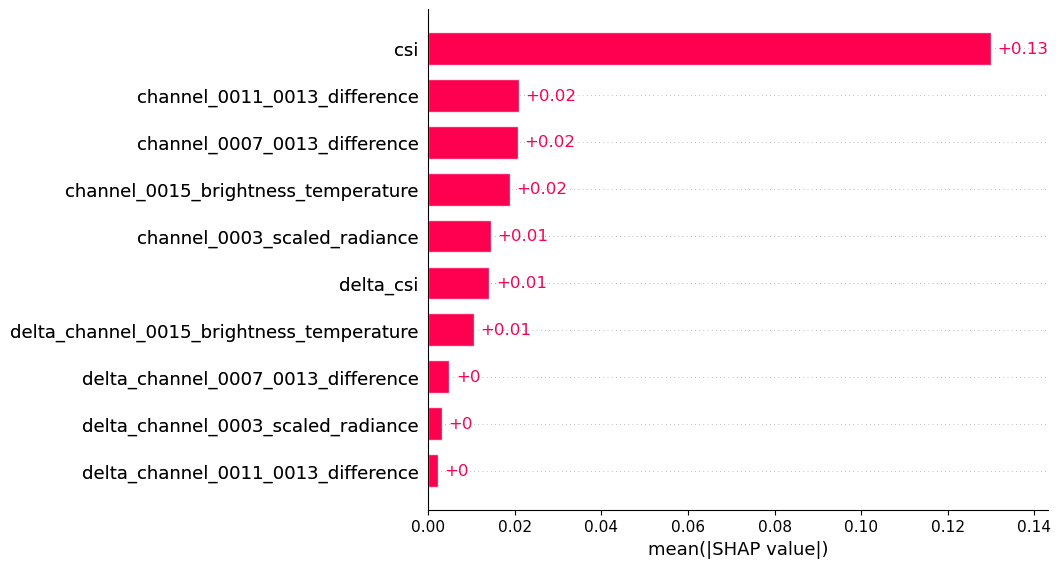

In [58]:
shap_values = shap_analysis(
    ds=ds_xgb,
    df=df,
    X_vars=X_vars,
    explainer=explainer
)

In [67]:
# ---- FEATURE IMPORTANCE from SHAP----
# so can be saved for later
importance = np.abs(shap_values.values).mean(axis=0)

importance_df = pd.DataFrame({
    "feature": X_vars,
    "mean_abs_shap": importance
})

Month: 02
XGBoost RMSE: 0.2133445596383765
Optical Flow RMSE: 0.24825142872885508
XGBoost SSIM: 0.3199870399328904
Optical Flow SSIM: 0.2934972449719561


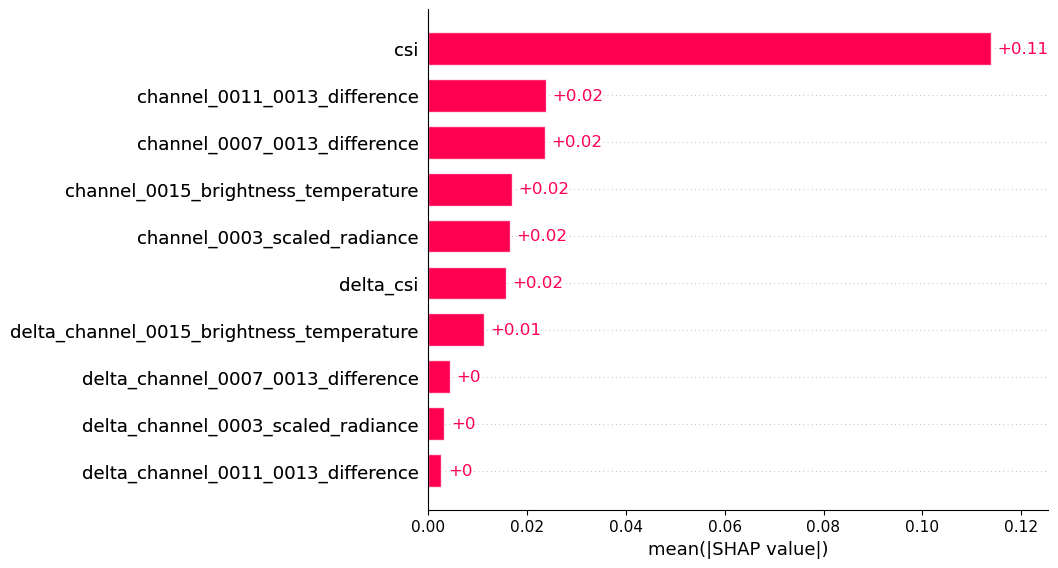

Month: 06
XGBoost RMSE: 0.20791480152111472
Optical Flow RMSE: 0.2541085824668476
XGBoost SSIM: 0.556551996342763
Optical Flow SSIM: 0.49714115204365605


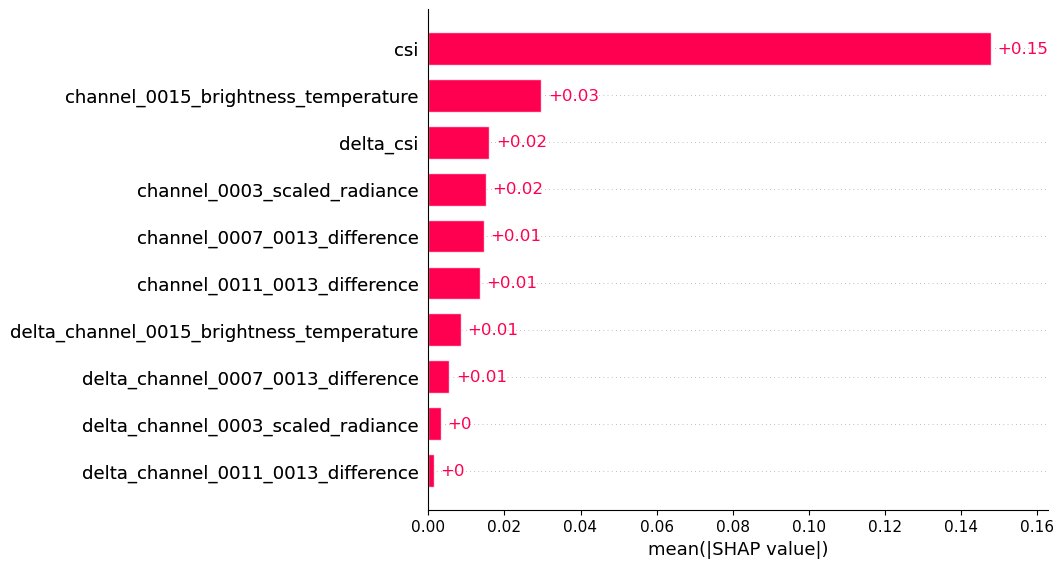

Month: 10
XGBoost RMSE: 0.14432055870695726
Optical Flow RMSE: 0.1683819182278921
XGBoost SSIM: 0.5634965801907009
Optical Flow SSIM: 0.466722110643972


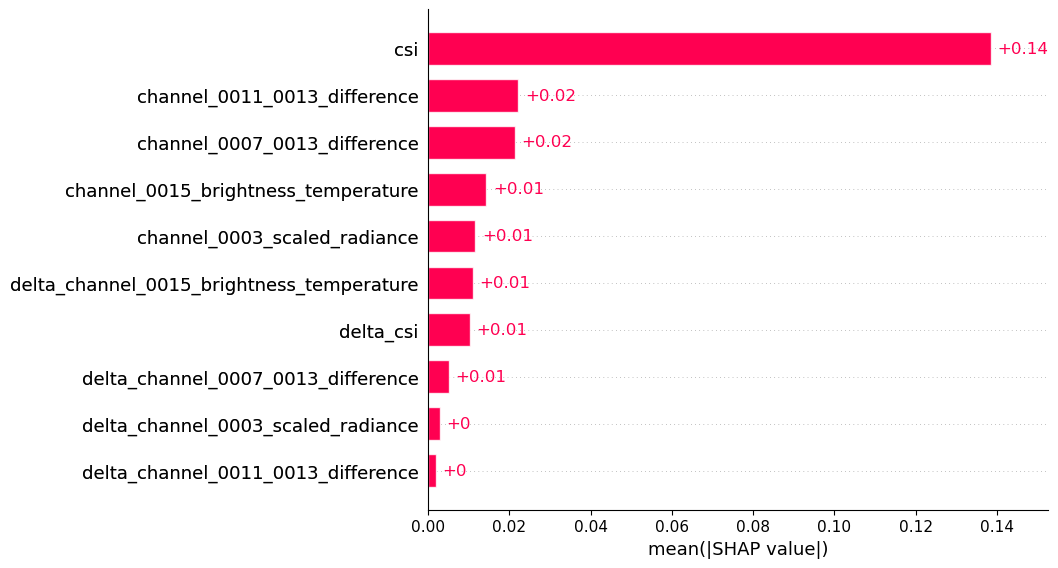

In [23]:
# RMSE by month

for month, month_ds in ds_xgb.groupby('time.month'):
    
    obs = month_ds[f'csi_t{forecast_lead}']
    fcst_xgb = month_ds[f'xgb_t{forecast_lead}']
    fcst_gso = ds_gso['csi_gso'].sel(time=month_ds.time)
    
    rmse_xgb = rmse(obs, fcst_xgb)
    rmse_gso = rmse(obs, fcst_gso)

    ssim_xgb = calc_ssim(obs, fcst_xgb)
    ssim_gso = calc_ssim(obs, fcst_gso)
    


    mod_metrics[f'rmse_month_{month:02d}'] = rmse_xgb
    gso_metrics[f'rmse_month_{month:02d}'] = rmse_gso
    mod_metrics[f'ssim_month_{month:02d}'] = ssim_xgb
    gso_metrics[f'ssim_month_{month:02d}'] = ssim_gso

    print(f"Month: {month:02d}")
    print(f"XGBoost RMSE: {rmse_xgb}")
    print(f"Optical Flow RMSE: {rmse_gso}")

    print(f"XGBoost SSIM: {ssim_xgb}")
    print(f"Optical Flow SSIM: {ssim_gso}")
    shap_values = shap_analysis(
        ds=month_ds,
        df=df,
        X_vars=X_vars,
        explainer=explainer
    )

CSI Range: 0 - 0.6
XGBoost RMSE: 0.2324208201075297
Optical Flow RMSE: 0.25832322388687234
XGBoost SSIM: 0.2838285798890888
Optical Flow SSIM: 0.26170414335040665


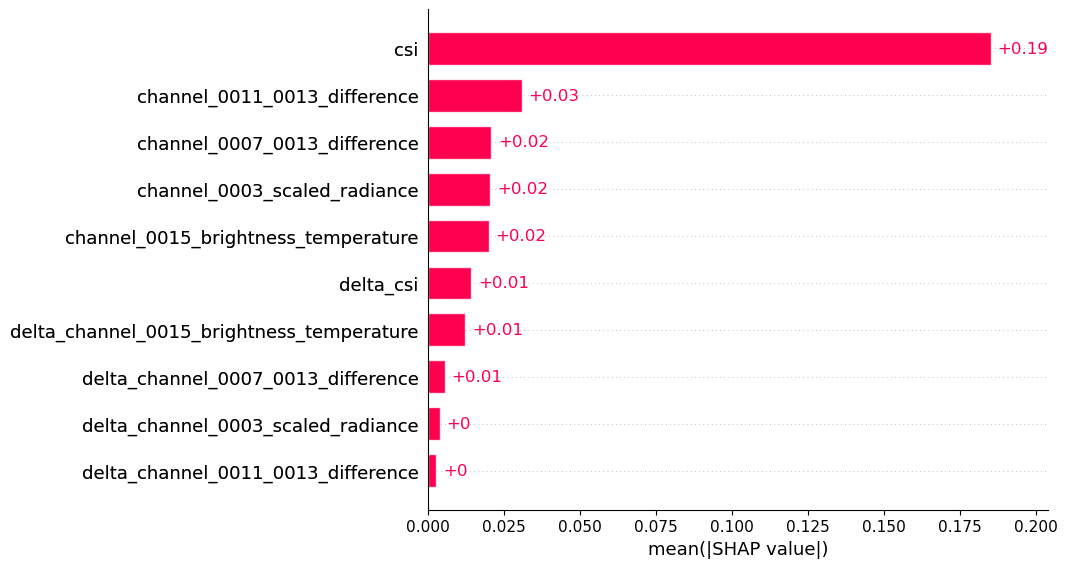

CSI Range: 0.6 - 0.8
XGBoost RMSE: 0.22069755383563275
Optical Flow RMSE: 0.2572959039336877
XGBoost SSIM: 0.39478981597392476
Optical Flow SSIM: 0.37383598702685


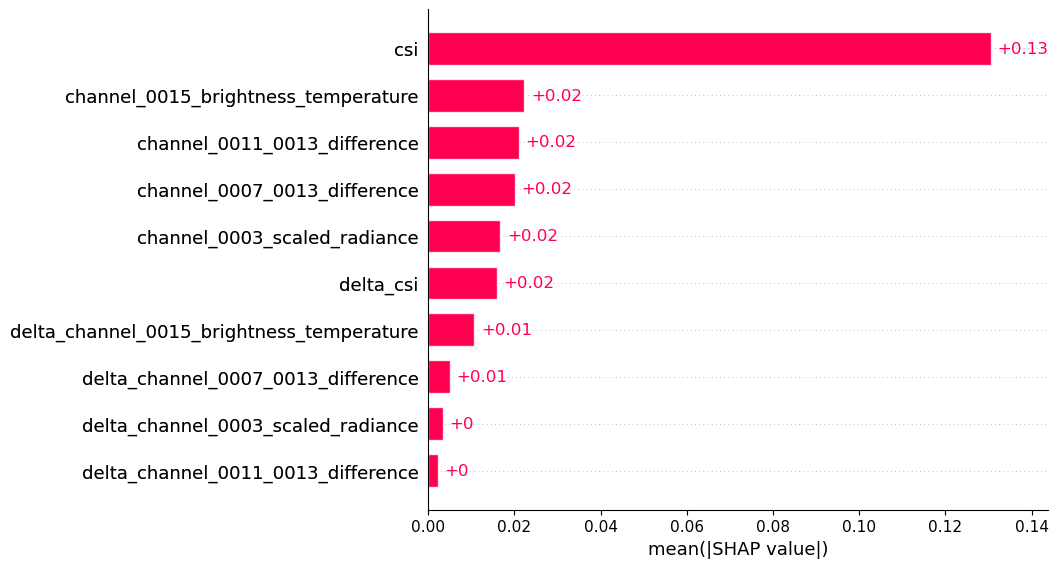

CSI Range: 0.8 - 10
XGBoost RMSE: 0.13751156021709285
Optical Flow RMSE: 0.17750442310297318
XGBoost SSIM: 0.5867504525637266
Optical Flow SSIM: 0.4839558644384283


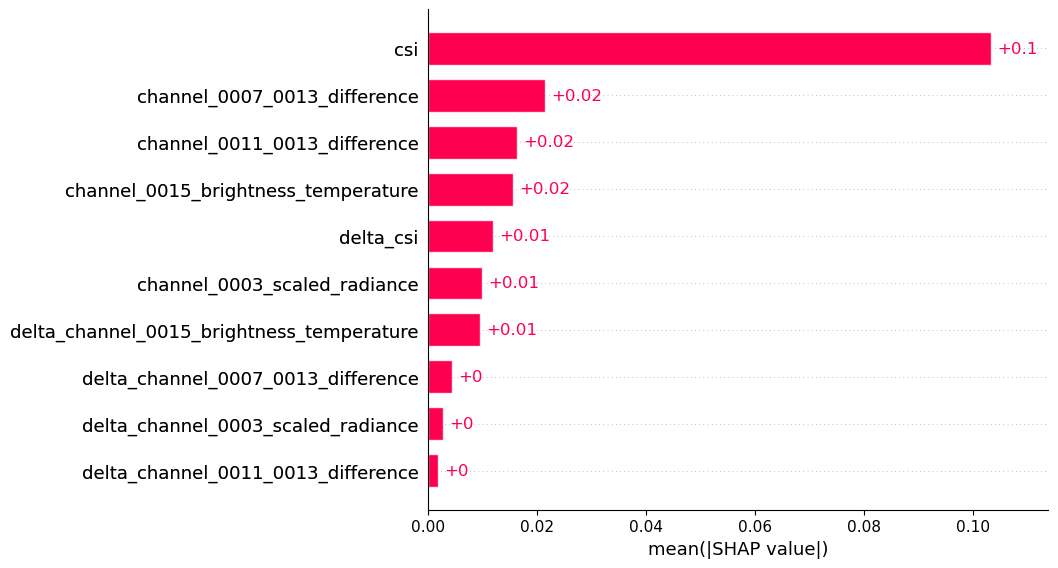

In [24]:
# By CSI magnitude

daily_mean_csi = ds_xgb[f'csi_t{forecast_lead}'].resample(time='1D').mean()
daily_regional_mean = daily_mean_csi.mean(['latitude', 'longitude'])

csi_ranges = [
    (0, 0.6, 'low'),
    (0.6, 0.8, 'med'),
    (0.8, 10, 'high'),
]

# Daily mean CSI
daily_mean_csi = ds_xgb[f'csi_t{forecast_lead}'].resample(time='1D').mean()

for csi_min, csi_max, name in csi_ranges:

    # Select days whose DAILY MEAN CSI falls in range
    valid_days = daily_regional_mean.time.where(
        (daily_regional_mean > csi_min) &
        (daily_regional_mean < csi_max),
        drop=True
    )
    # Get dates only
    valid_dates = valid_days.dt.floor('D')

    # Match all timestamps belonging to those days
    mask = ds_xgb.time.dt.floor('D').isin(valid_dates)
    ds_range = ds_xgb.where(mask, drop=True)

    obs = ds_range[f'csi_t{forecast_lead}']
    fcst_xgb = ds_range[f'xgb_t{forecast_lead}']
    fcst_gso = ds_gso['csi_gso'].sel(time=ds_range.time)


    rmse_xgb = rmse(obs, fcst_xgb)
    rmse_gso = rmse(obs, fcst_gso)
    ssim_xgb = calc_ssim(obs, fcst_xgb)
    ssim_gso = calc_ssim(obs, fcst_gso)
    

    mod_metrics[f'rmse_csi_{name}'] = rmse_xgb
    gso_metrics[f'rmse_csi_{name}'] = rmse_gso
    mod_metrics[f'ssim_csi_{name}'] = ssim_xgb
    gso_metrics[f'ssim_csi_{name}'] = ssim_gso

    print(f"CSI Range: {csi_min} - {csi_max}")
    print(f"XGBoost RMSE: {rmse_xgb}")
    print(f"Optical Flow RMSE: {rmse_gso}")
    print(f"XGBoost SSIM: {ssim_xgb}")
    print(f"Optical Flow SSIM: {ssim_gso}")

    shap_values = shap_analysis(
        ds=ds_range,
        df=df,
        X_vars=X_vars,
        explainer=explainer
    )

Delta Range: -10 - -0.1
XGBoost RMSE: 0.22261837185899258
Optical Flow RMSE: 0.2682581981826755
XGBoost SSIM: 0.4446617742089813
Optical Flow SSIM: 0.4344935748494631


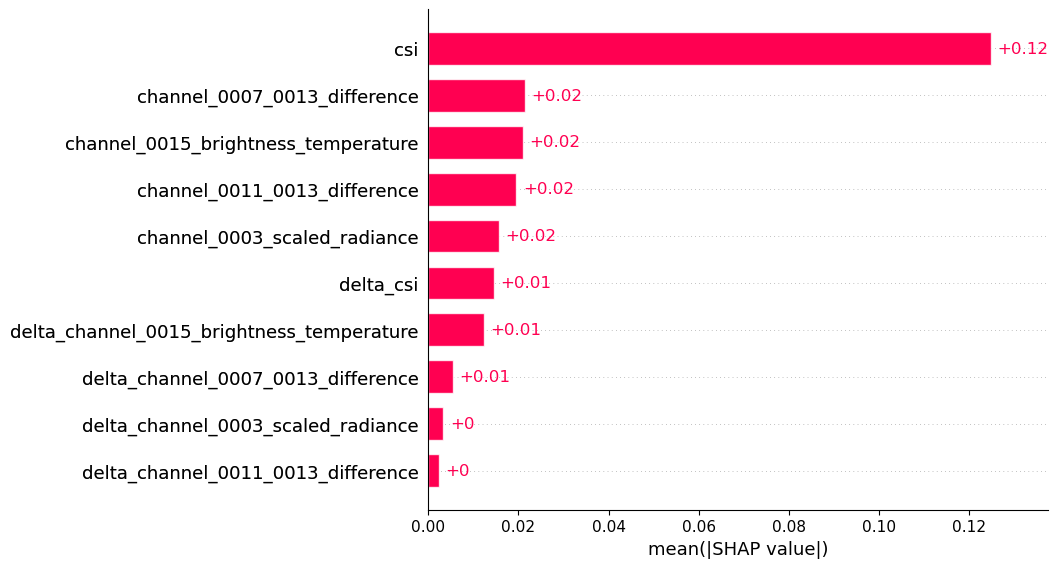

Delta Range: -0.1 - 0.0
XGBoost RMSE: 0.1835418905294978
Optical Flow RMSE: 0.2154364387225871
XGBoost SSIM: 0.4593811444243799
Optical Flow SSIM: 0.39827731978139336


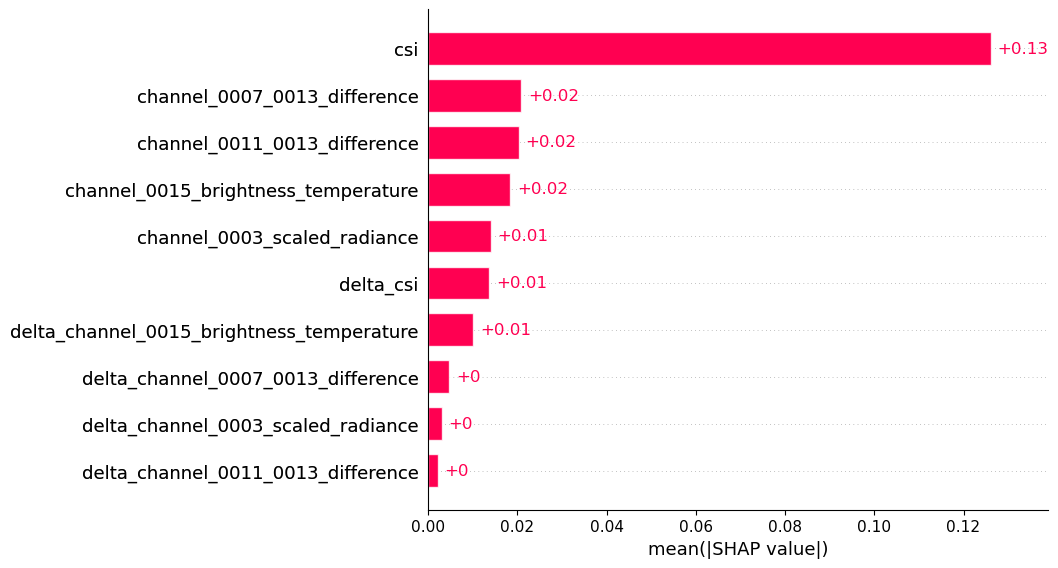

Delta Range: 0.0 - 10
XGBoost RMSE: 0.2058580851701662
Optical Flow RMSE: 0.24081844647759784
XGBoost SSIM: 0.6344404870131021
Optical Flow SSIM: 0.5840760961737818


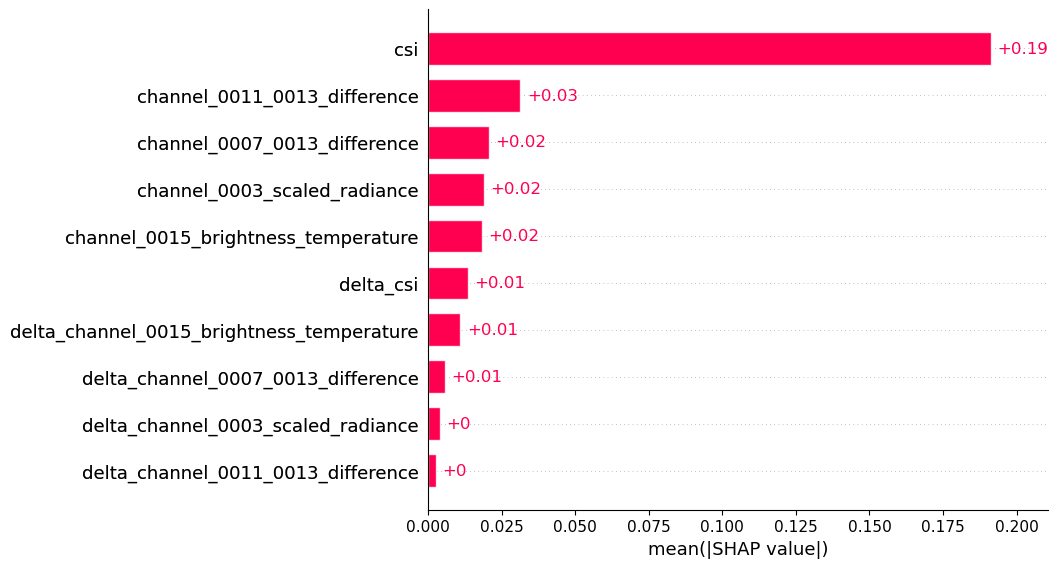

In [25]:
# By change in CSI

reg_mean = ds_xgb.mean(['latitude', 'longitude'])
reg_mean_delta = reg_mean[f'csi_t{forecast_lead}'] - reg_mean['csi']

delta_range = [
    (-10, -0.1, 'grow'),
    (-0.1, 0.0, 'stable'),
    (0.0, 10, 'shrink')
]

for delta_min, delta_max, name in delta_range:
    
    valid_times = reg_mean_delta.time.where(
        (reg_mean_delta > delta_min) &
        (reg_mean_delta < delta_max),
        drop=True
    )

    # Match all timestamps belonging to those days
    mask = ds_xgb.time.isin(valid_times)
    ds_range = ds_xgb.where(mask, drop=True)

    obs = ds_range[f'csi_t{forecast_lead}']
    fcst_xgb = ds_range[f'xgb_t{forecast_lead}']
    fcst_gso = ds_gso['csi_gso'].sel(time=ds_range.time)


    rmse_xgb = rmse(obs, fcst_xgb)
    rmse_gso = rmse(obs, fcst_gso)
    ssim_xgb = calc_ssim(obs, fcst_xgb)
    ssim_gso = calc_ssim(obs, fcst_gso)
    

    mod_metrics[f'rmse_delta_{name}'] = rmse_xgb
    gso_metrics[f'rmse_delta_{name}'] = rmse_gso
    mod_metrics[f'ssim_delta_{name}'] = ssim_xgb
    gso_metrics[f'ssim_delta_{name}'] = ssim_gso


    print(f"Delta Range: {delta_min} - {delta_max}")
    print(f"XGBoost RMSE: {rmse_xgb}")
    print(f"Optical Flow RMSE: {rmse_gso}")
    print(f"XGBoost SSIM: {ssim_xgb}")
    print(f"Optical Flow SSIM: {ssim_gso}")
    
    shap_values = shap_analysis(
        ds=ds_range,
        df=df,
        X_vars=X_vars,
        explainer=explainer
    )


In [41]:
df_metrics = pd.DataFrame(mod_metrics, index=[model_name])
df_metrics_gso = pd.DataFrame(gso_metrics, index=['GSO_OF'])

In [48]:
# Save the results from metric tests

save_path = Path('/scratch/er8/cd3022/xgb_eval/')
os.makedirs(save_path, exist_ok=True)

df_metrics.to_csv(f'/scratch/er8/cd3022/xgb_eval/{model_name}_metrics.csv')
df_metrics_gso.to_csv('/scratch/er8/cd3022/xgb_eval/gso_of_metrics.csv')